# Laby 4. Bank Customer Churn — Drzewa Decyzyjne

## 1. Analiza i preprocessing zbioru danych

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style="whitegrid")

In [103]:
df = pd.read_csv("data/Customer-Churn-Records.csv")

print("Kształt zbioru:", df.shape)
print("\nPierwsze wiersze:")
df.head()

Kształt zbioru: (10000, 18)

Pierwsze wiersze:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [104]:
print("=== Typy danych ===")
print(df.dtypes)

print("\n=== Brakujące wartości ===")
print(df.isnull().sum())

print("\n=== Statystyki opisowe ===")
df.describe()

=== Typy danych ===
RowNumber               int64
CustomerId              int64
Surname                   str
CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object

=== Brakujące wartości ===
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type     

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


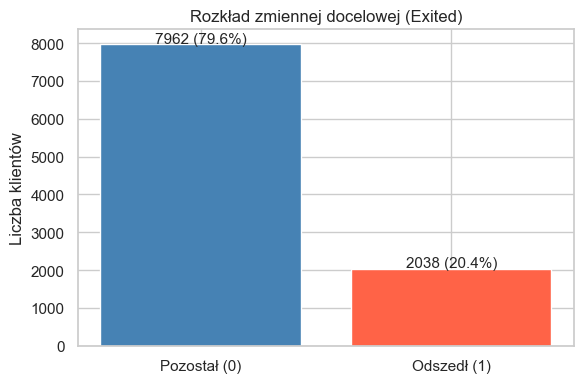


Niezbalansowanie klas: 3.9:1


In [105]:
# Rozkład zmiennej docelowej

churn_counts = df["Exited"].value_counts()
labels = ["Pozostał (0)", "Odszedł (1)"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, churn_counts, color=["steelblue", "tomato"])
for bar, count in zip(bars, churn_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{count} ({count/len(df)*100:.1f}%)", ha="center", fontsize=11)

plt.title("Rozkład zmiennej docelowej (Exited)")
plt.ylabel("Liczba klientów")
plt.tight_layout()
plt.show()

print(f"\nNiezbalansowanie klas: {churn_counts[0]/churn_counts[1]:.1f}:1")

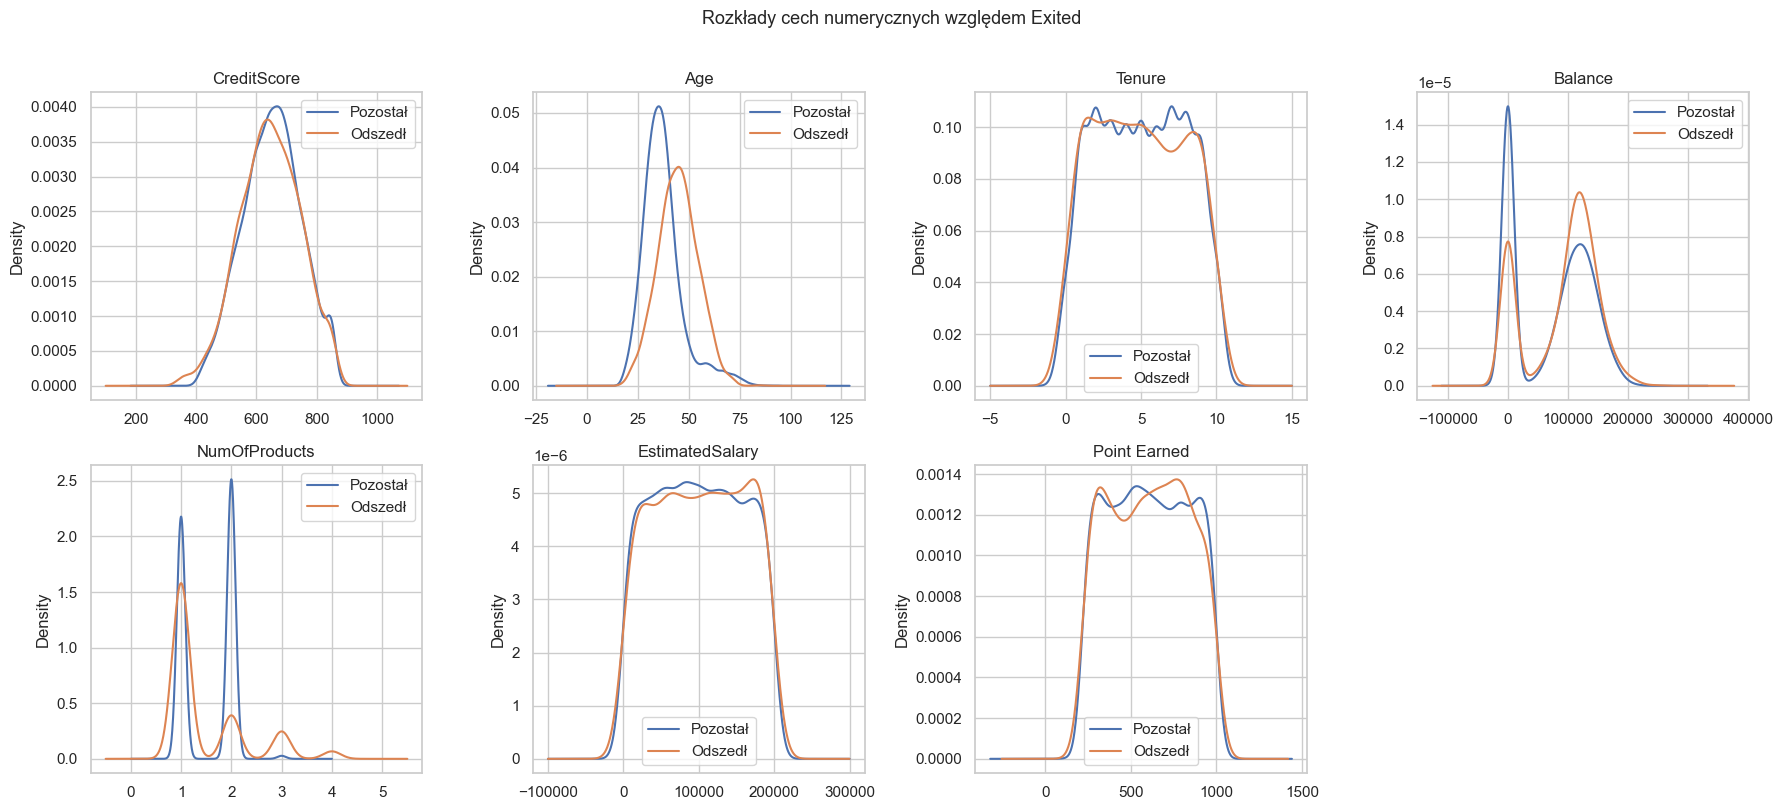

In [106]:
# Analiza cech numerycznych

num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
            "EstimatedSalary", "Point Earned"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.groupby("Exited")[col].plot(
        kind="kde", ax=axes[i], legend=True,
        title=col
    )
    axes[i].legend(["Pozostał", "Odszedł"])

axes[-1].set_visible(False)
plt.suptitle("Rozkłady cech numerycznych względem Exited", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

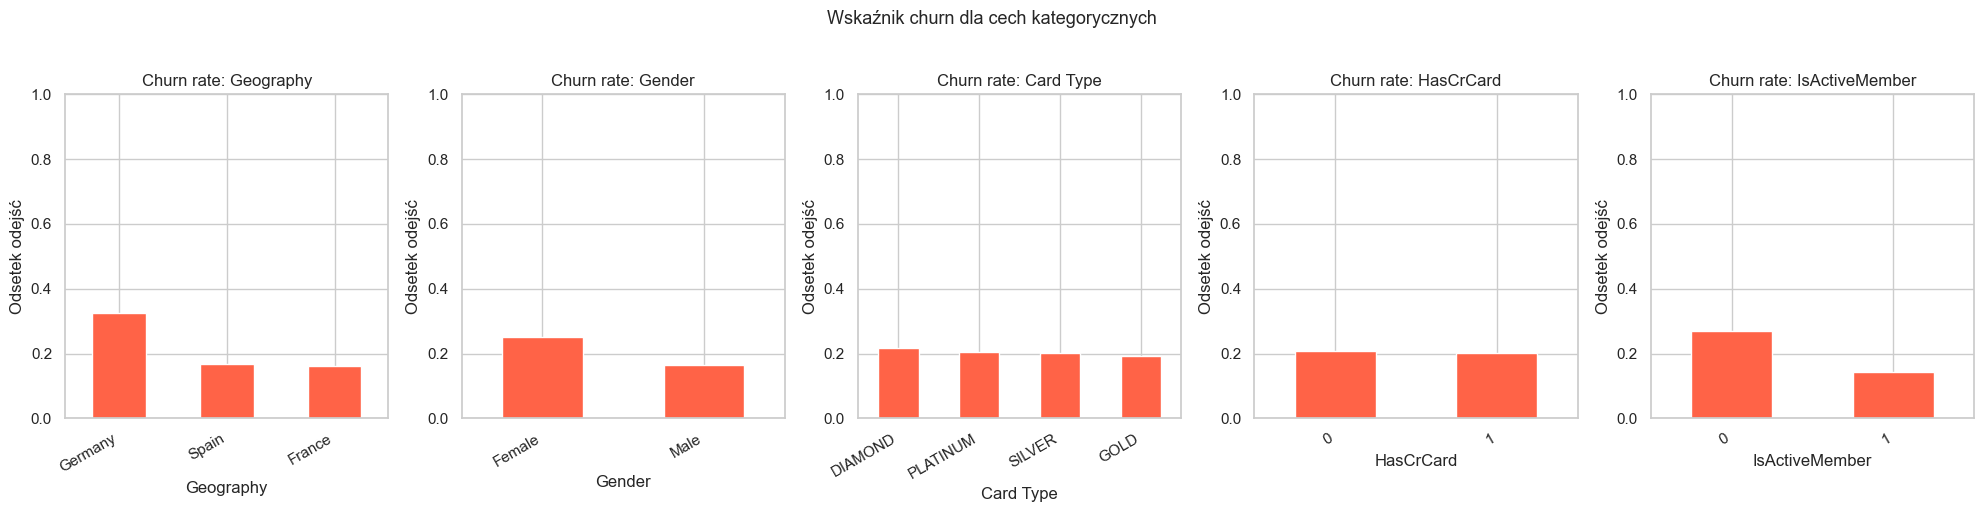

In [107]:
# Analiza cech kategorycznych

cat_cols = ["Geography", "Gender", "Card Type", "HasCrCard", "IsActiveMember"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 5))

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)["Exited"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
    ax.set_title(f"Churn rate: {col}")
    ax.set_ylabel("Odsetek odejść")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_ylim(0, 1)

plt.suptitle("Wskaźnik churn dla cech kategorycznych", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [108]:
# Outliers (IQR)

def detect_outliers_iqr(data, col):
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

print("=== Analiza outlierów (IQR) ===")
for col in num_cols:
    n, lo, hi = detect_outliers_iqr(df, col)
    print(f"{col:20s}  outlierów: {n:4d}  zakres: [{lo:.1f}, {hi:.1f}]")

=== Analiza outlierów (IQR) ===
CreditScore           outlierów:   15  zakres: [383.0, 919.0]
Age                   outlierów:  359  zakres: [14.0, 62.0]
Tenure                outlierów:    0  zakres: [-3.0, 13.0]
Balance               outlierów:    0  zakres: [-191466.4, 319110.6]
NumOfProducts         outlierów:   60  zakres: [-0.5, 3.5]
EstimatedSalary       outlierów:    0  zakres: [-96577.1, 296967.5]
Point Earned          outlierów:    0  zakres: [-176.5, 1387.5]


In [109]:
# Preprocessing

# Usunięcie kolumn nieprzydatnych do modelowania
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname", "Complain"])

# Encoding zmiennych kategorycznych
le = LabelEncoder()
cat_encode_cols = ["Geography", "Gender", "Card Type"]

for col in cat_encode_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nPodgląd:")
df_clean.head()


Podgląd:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,2,0,464
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,3,0,456
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,3,0,377
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,5,1,350
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,5,1,425


In [110]:
# Podział na zbiór treningowy i testowy

X = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Zbiór treningowy: {X_train.shape}")
print(f"Zbiór testowy:    {X_test.shape}")
print(f"\nRozkład klas treningowych:\n{y_train.value_counts()}")
print(f"\nRozkład klas testowych:\n{y_test.value_counts()}")

Zbiór treningowy: (8000, 13)
Zbiór testowy:    (2000, 13)

Rozkład klas treningowych:
Exited
0    6370
1    1630
Name: count, dtype: int64

Rozkład klas testowych:
Exited
0    1592
1     408
Name: count, dtype: int64


In [111]:
# Skalowanie cech

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Skalowanie zakończone.")
print("Przykładowe statystyki po skalowaniu:")
X_train_scaled.describe().round(2)

Skalowanie zakończone.
Przykładowe statystyki po skalowaniu:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.11,-0.90,-1.10,-1.98,-1.73,-1.23,-0.91,-1.56,-1.03,-1.73,-1.43,-1.35,-2.15
25%,-0.69,-0.90,-1.10,-0.66,-0.70,-1.23,-0.91,-1.56,-1.03,-0.86,-0.72,-0.45,-0.87
50%,0.01,-0.90,0.91,-0.18,-0.00,0.33,-0.91,0.64,0.97,-0.01,-0.01,-0.45,-0.01
75%,0.70,0.30,0.91,0.48,1.03,0.82,0.81,0.64,0.97,0.85,0.70,0.45,0.86
max,2.06,1.51,0.91,5.03,1.73,2.60,4.24,0.64,0.97,1.75,1.41,1.35,1.74


## 2. Uruchomienie klasyfikatora

In [112]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [113]:
# Bazowy model

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_scaled, y_train)

y_pred_base = dt_base.predict(X_test_scaled)

print("=== Model bazowy (domyślne hiperparametry) ===")
print(classification_report(y_test, y_pred_base, target_names=["Pozostał", "Odszedł"]))

=== Model bazowy (domyślne hiperparametry) ===
              precision    recall  f1-score   support

    Pozostał       0.88      0.85      0.87      1592
     Odszedł       0.49      0.55      0.52       408

    accuracy                           0.79      2000
   macro avg       0.68      0.70      0.69      2000
weighted avg       0.80      0.79      0.79      2000



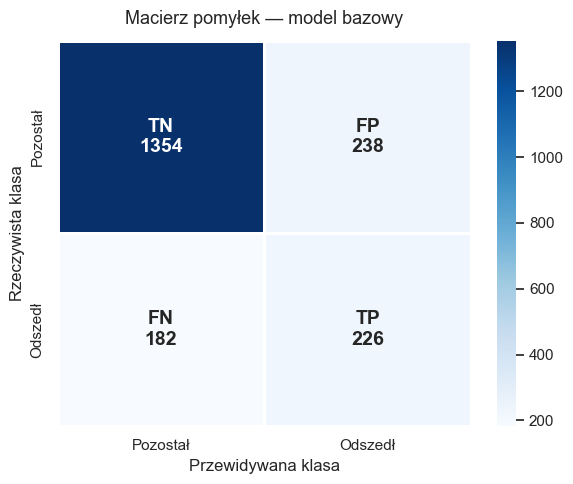

TN: 1354  FP: 238  FN: 182  TP: 226


In [114]:
cm = confusion_matrix(y_test, y_pred_base)
tn, fp, fn, tp = cm.ravel()

labels = np.array([
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=labels, fmt="", cmap="Blues",
    xticklabels=["Pozostał", "Odszedł"],
    yticklabels=["Pozostał", "Odszedł"],
    linewidths=1, linecolor="white",
    annot_kws={"size": 14, "weight": "bold"}
)
ax.set_xlabel("Przewidywana klasa", fontsize=12)
ax.set_ylabel("Rzeczywista klasa", fontsize=12)
ax.set_title("Macierz pomyłek — model bazowy", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print(f"TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

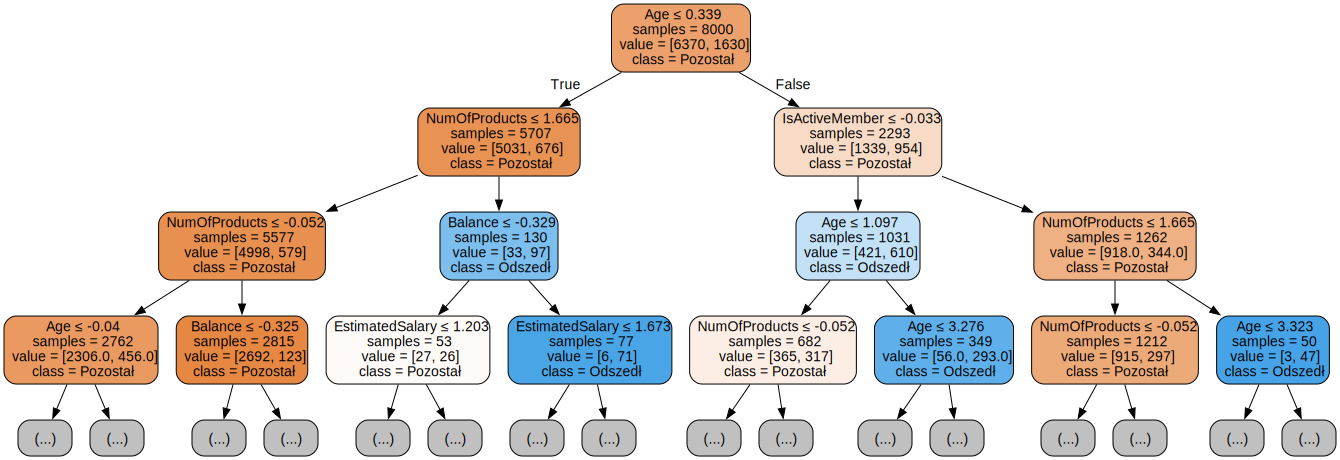

In [115]:
# Wizualizacja drzewa (uproszczona) 

from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_base,
    max_depth=3,
    feature_names=X_train_scaled.columns.tolist(),
    class_names=["Pozostał", "Odszedł"],
    filled=True,
    rounded=True,
    special_characters=True,
    proportion=False,
    impurity=False,        # ukrycie gini — czytelniej
    out_file=None
)

graph = graphviz.Source(dot_data)
graph

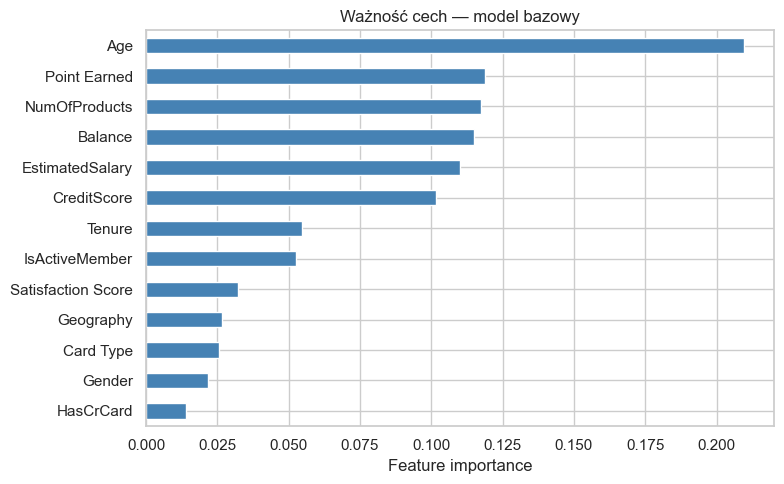

In [116]:
# Ważność cech

importances = pd.Series(dt_base.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("Ważność cech — model bazowy")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

## 3. Wybór i uzasadnienie miar klasyfikacji

In [117]:
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)

In [118]:
# Dlaczego nie accuracy?

print("=== Analiza niezbalansowania klas ===")
print(f"Klasa 0 (Pozostał): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"Klasa 1 (Odszedł):  {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

dummy_accuracy = (y_test == 0).mean()
print(f"\nModel zawsze przewidujący 'Pozostał' osiągnąłby accuracy: {dummy_accuracy:.2%}")
print("Taki model byłby bezużyteczny biznesowo — nie wykryłby żadnego odchodzącego klienta.")

=== Analiza niezbalansowania klas ===
Klasa 0 (Pozostał): 1592 (79.6%)
Klasa 1 (Odszedł):  408 (20.4%)

Model zawsze przewidujący 'Pozostał' osiągnąłby accuracy: 79.60%
Taki model byłby bezużyteczny biznesowo — nie wykryłby żadnego odchodzącego klienta.


In [119]:
# Wybór metryk i uzasadnienie

print("=== Wybrane metryki klasyfikacji ===\n")
print(f"{'Metryka':<12} {'Uzasadnienie'}")
print("-" * 72)
print(f"{'Recall':<12} Ile odchodzących klientów wykryliśmy — każdy przeoczony (FN) to utracony przychód")
print(f"{'Precision':<12} Ile alarmów było trafnych — fałszywy alarm (FP) to niepotrzebna zniżka")
print(f"{'F1-score':<12} Kompromis między recall i precision — przydatny do porównania modeli")
print(f"{'ROC-AUC':<12} Ogólna zdolność rozróżniania klas niezależnie od progu decyzyjnego")

=== Wybrane metryki klasyfikacji ===

Metryka      Uzasadnienie
------------------------------------------------------------------------
Recall       Ile odchodzących klientów wykryliśmy — każdy przeoczony (FN) to utracony przychód
Precision    Ile alarmów było trafnych — fałszywy alarm (FP) to niepotrzebna zniżka
F1-score     Kompromis między recall i precision — przydatny do porównania modeli
ROC-AUC      Ogólna zdolność rozróżniania klas niezależnie od progu decyzyjnego


In [ ]:
# Interpretacja wyników modelu bazowego

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_base).ravel()

print("=== Interpretacja wyników modelu bazowego (kontekst biznesowy) ===\n")
print(f"Recall    = {recall_score(y_test, y_pred_base):.3f}")
print(f"  → Model przeoczył {fn} odchodzących klientów (FN) — bank traci tych klientów całkowicie.\n")
print(f"Precision = {precision_score(y_test, y_pred_base):.3f}")
print(f"  → {fp} lojalnych klientów otrzymało niepotrzebną zniżkę (FP) — zbędny koszt dla banku.\n")
print(f"F1-score  = {f1_score(y_test, y_pred_base):.3f}")
print(f"ROC-AUC   = {roc_auc_score(y_test, dt_base.predict_proba(X_test_scaled)[:, 1]):.3f}\n")
print("Sama wartość metryk nie wystarcza — poniżej przekładamy FP/FN na konkretne dolary.")

=== Interpretacja wyników modelu bazowego (kontekst biznesowy) ===

Recall    = 0.554
  → Model przeoczył 182 odchodzących klientów (FN) — bank traci tych klientów całkowicie.

Precision = 0.487
  → 238 lojalnych klientów otrzymało niepotrzebną zniżkę (FP) — zbędny koszt dla banku.

F1-score  = 0.518
ROC-AUC   = 0.702

Sama wartość metryk nie wystarcza — poniżej przekładamy FP/FN na konkretne dolary.


In [121]:
# Metryka biznesowa (zysk banku)

def calculate_profit(y_true, y_pred, salaries):
    """
    Oblicza całkowity zysk banku na podstawie predykcji modelu.

    TN: lojalny, brak zniżki       → zarabiamy 0.3% salary
    FP: lojalny, dostaje zniżkę    → zarabiamy 0.1% salary (niepotrzebna zniżka)
    TP: odchodzący, dostaje zniżkę → zostaje    → zarabiamy 0.1% salary
    FN: odchodzący, brak zniżki    → odchodzi   → zarabiamy 0%
    """
    y_true   = np.array(y_true)
    y_pred   = np.array(y_pred)
    salaries = np.array(salaries)

    profit = (
          0.003 * salaries * ((y_true == 0) & (y_pred == 0))  # TN
        + 0.001 * salaries * ((y_true == 0) & (y_pred == 1))  # FP
        + 0.001 * salaries * ((y_true == 1) & (y_pred == 1))  # TP
        + 0.0   * salaries * ((y_true == 1) & (y_pred == 0))  # FN
    )
    return profit.sum()

salaries_test_orig = df.loc[X_test.index, "EstimatedSalary"].values

profit_model   = calculate_profit(y_test, y_pred_base, salaries_test_orig)
profit_all_no  = calculate_profit(y_test, np.zeros_like(y_pred_base), salaries_test_orig)
profit_all_yes = calculate_profit(y_test, np.ones_like(y_pred_base),  salaries_test_orig)

print("=== Porównanie zysku banku ===\n")
print(f"{'Strategia':<35} {'Zysk':>12}")
print("-" * 50)
print(f"{'Brak modelu (nikt nie dostaje zniżki)':<35} ${profit_all_no:>11,.2f}")
print(f"{'Wszyscy dostają zniżkę':<35} ${profit_all_yes:>11,.2f}")
print(f"{'Model bazowy (drzewo decyzyjne)':<35} ${profit_model:>11,.2f}")
print(f"\nZysk ponad baseline (brak modelu): ${profit_model - profit_all_no:+,.2f}")

=== Porównanie zysku banku ===

Strategia                                   Zysk
--------------------------------------------------
Brak modelu (nikt nie dostaje zniżki) $ 490,167.43
Wszyscy dostają zniżkę              $ 204,746.39
Model bazowy (drzewo decyzyjne)     $ 464,927.49

Zysk ponad baseline (brak modelu): $-25,239.95


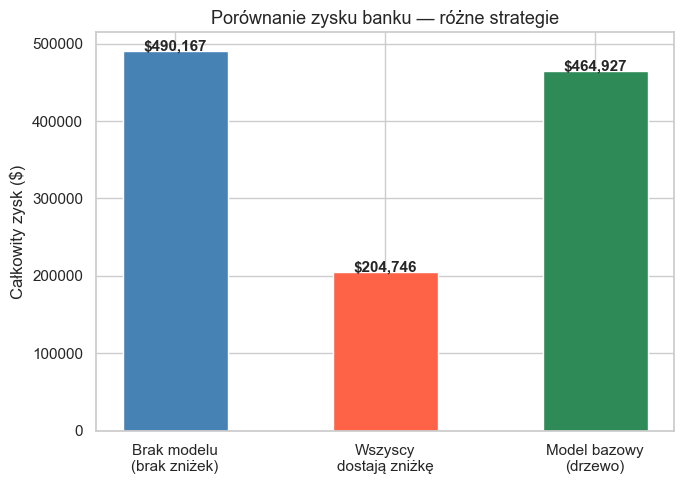

In [122]:
# Wizualizacja porównania zysku

strategies = ["Brak modelu\n(brak zniżek)", "Wszyscy\ndostają zniżkę", "Model bazowy\n(drzewo)"]
profits    = [profit_all_no, profit_all_yes, profit_model]
colors     = ["steelblue", "tomato", "seagreen"]

plt.figure(figsize=(7, 5))
bars = plt.bar(strategies, profits, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, profits):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"${val:,.0f}", ha="center", fontsize=11, fontweight="bold")
plt.title("Porównanie zysku banku — różne strategie", fontsize=13)
plt.ylabel("Całkowity zysk ($)")
plt.tight_layout()
plt.show()

## 4. Hiperparametry i walidacja krzyżowa

In [123]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

In [ ]:
# Do walidacji krzyżowej używamy F1-score jako metryki optymalizacji.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

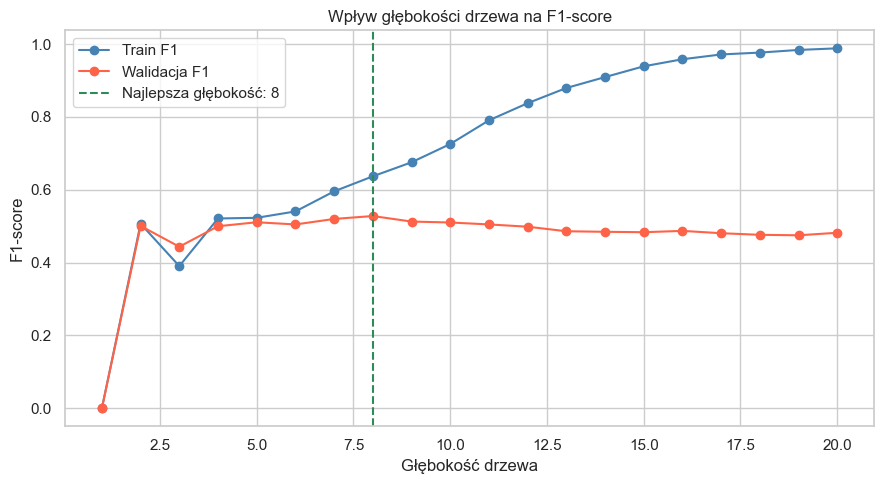

Najlepsza głębokość (walidacja): 8


In [125]:
# Badanie głębokości drzewa

depths = range(1, 21)

train_scores, val_scores = [], []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train_scaled)))
    val_scores.append(
        cross_val_score(dt, X_train_scaled, y_train, cv=cv, scoring="f1").mean()
    )

best_depth = depths[np.argmax(val_scores)]

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, "o-", label="Train F1",     color="steelblue")
plt.plot(depths, val_scores,   "o-", label="Walidacja F1", color="tomato")
plt.axvline(best_depth, linestyle="--", color="seagreen",
            label=f"Najlepsza głębokość: {best_depth}")
plt.xlabel("Głębokość drzewa")
plt.ylabel("F1-score")
plt.title("Wpływ głębokości drzewa na F1-score")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Najlepsza głębokość (walidacja): {best_depth}")

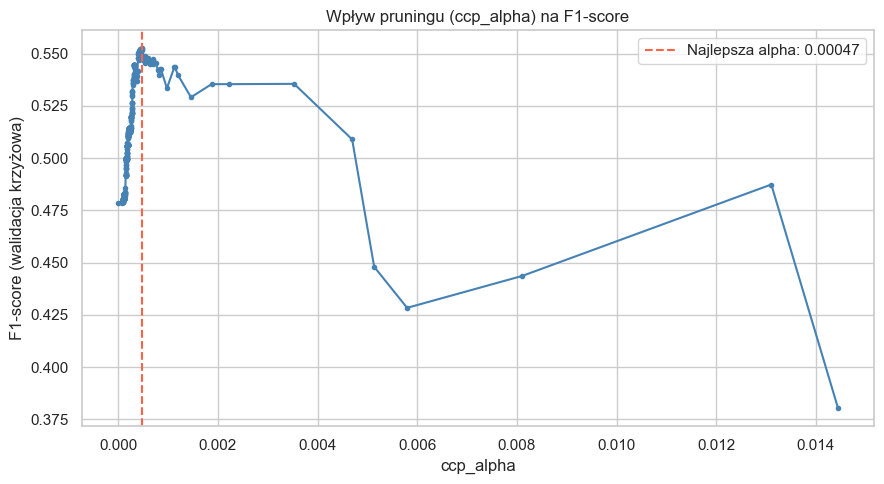

Najlepsza ccp_alpha: 0.00047


In [126]:
# Badanie pruningu (ccp_alpha)

dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_scaled, y_train)

path       = dt_full.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # ostatni to puste drzewo

val_f1_pruning = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    val_f1_pruning.append(
        cross_val_score(dt, X_train_scaled, y_train, cv=cv, scoring="f1").mean()
    )

best_alpha = ccp_alphas[np.argmax(val_f1_pruning)]

plt.figure(figsize=(9, 5))
plt.plot(ccp_alphas, val_f1_pruning, "o-", color="steelblue", markersize=3)
plt.axvline(best_alpha, linestyle="--", color="tomato",
            label=f"Najlepsza alpha: {best_alpha:.5f}")
plt.xlabel("ccp_alpha")
plt.ylabel("F1-score (walidacja krzyżowa)")
plt.title("Wpływ pruningu (ccp_alpha) na F1-score")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Najlepsza ccp_alpha: {best_alpha:.5f}")

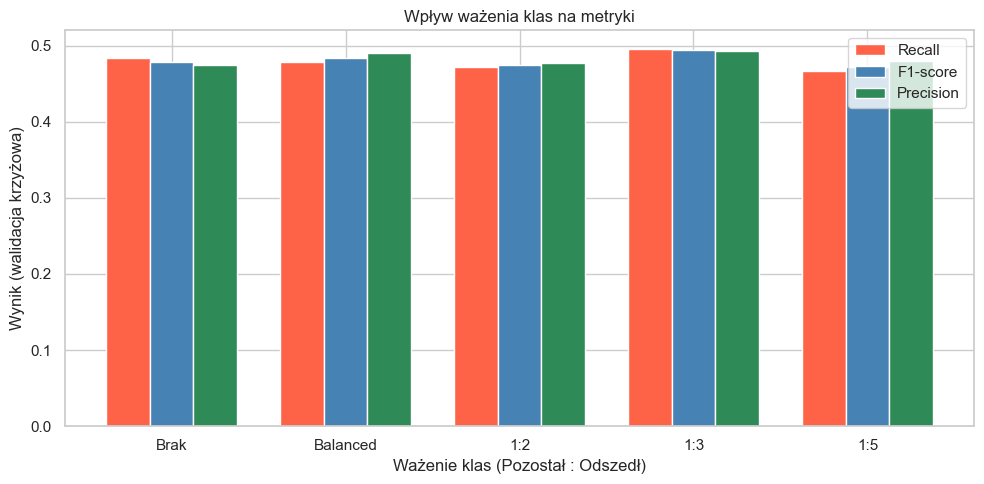

In [127]:
# Badanie ważenia klas
class_weights = [None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}]
weight_labels = ["Brak", "Balanced", "1:2", "1:3", "1:5"]

recall_scores, precision_scores, f1_scores = [], [], []

for cw in class_weights:
    dt = DecisionTreeClassifier(class_weight=cw, random_state=42)
    recall_scores.append(
        cross_val_score(dt, X_train_scaled, y_train, cv=cv, scoring="recall").mean()
    )
    precision_scores.append(
        cross_val_score(dt, X_train_scaled, y_train, cv=cv, scoring="precision").mean()
    )
    f1_scores.append(
        cross_val_score(dt, X_train_scaled, y_train, cv=cv, scoring="f1").mean()
    )

x     = np.arange(len(weight_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, recall_scores,    width, label="Recall",    color="tomato")
ax.bar(x,         f1_scores,        width, label="F1-score",  color="steelblue")
ax.bar(x + width, precision_scores, width, label="Precision", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(weight_labels)
ax.set_xlabel("Ważenie klas (Pozostał : Odszedł)")
ax.set_ylabel("Wynik (walidacja krzyżowa)")
ax.set_title("Wpływ ważenia klas na metryki")
ax.legend()
plt.tight_layout()
plt.show()

In [128]:
# GridSearchCV

param_grid = {
    "max_depth":    [3, 5, 7, 10, None],
    "ccp_alpha":    [0.0, 0.0001, 0.0005, 0.001, 0.005],
    "class_weight": [None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 3}],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("=== Najlepsze hiperparametry ===")
print(grid_search.best_params_)
print(f"Najlepszy F1 (walidacja): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
=== Najlepsze hiperparametry ===
{'ccp_alpha': 0.001, 'class_weight': {0: 1, 1: 2}, 'max_depth': 5}
Najlepszy F1 (walidacja): 0.5835


In [129]:
# Porównanie model bazowy vs optymalny

dt_best     = grid_search.best_estimator_
y_pred_best = dt_best.predict(X_test_scaled)

metrics = {
    "Recall":    [recall_score(y_test, y_pred_base),    recall_score(y_test, y_pred_best)],
    "Precision": [precision_score(y_test, y_pred_base), precision_score(y_test, y_pred_best)],
    "F1-score":  [f1_score(y_test, y_pred_base),        f1_score(y_test, y_pred_best)],
    "ROC-AUC":   [roc_auc_score(y_test, dt_base.predict_proba(X_test_scaled)[:, 1]),
                  roc_auc_score(y_test, dt_best.predict_proba(X_test_scaled)[:, 1])],
}

df_metrics = pd.DataFrame(metrics, index=["Model bazowy", "Model optymalny"]).T
print("=== Porównanie metryk ===")
print(df_metrics.round(4))

profit_best = calculate_profit(y_test, y_pred_best, salaries_test_orig)
print(f"\n=== Porównanie zysku banku ===")
print(f"Brak modelu:     ${profit_all_no:>10,.2f}")
print(f"Model bazowy:    ${profit_model:>10,.2f}")
print(f"Model optymalny: ${profit_best:>10,.2f}")
print(f"\nZysk ponad baseline: ${profit_best - profit_all_no:+,.2f}")

=== Porównanie metryk ===
           Model bazowy  Model optymalny
Recall           0.5539           0.6029
Precision        0.4871           0.6029
F1-score         0.5183           0.6029
ROC-AUC          0.7022           0.8482

=== Porównanie zysku banku ===
Brak modelu:     $490,167.43
Model bazowy:    $464,927.49
Model optymalny: $486,174.00

Zysk ponad baseline: $-3,993.43


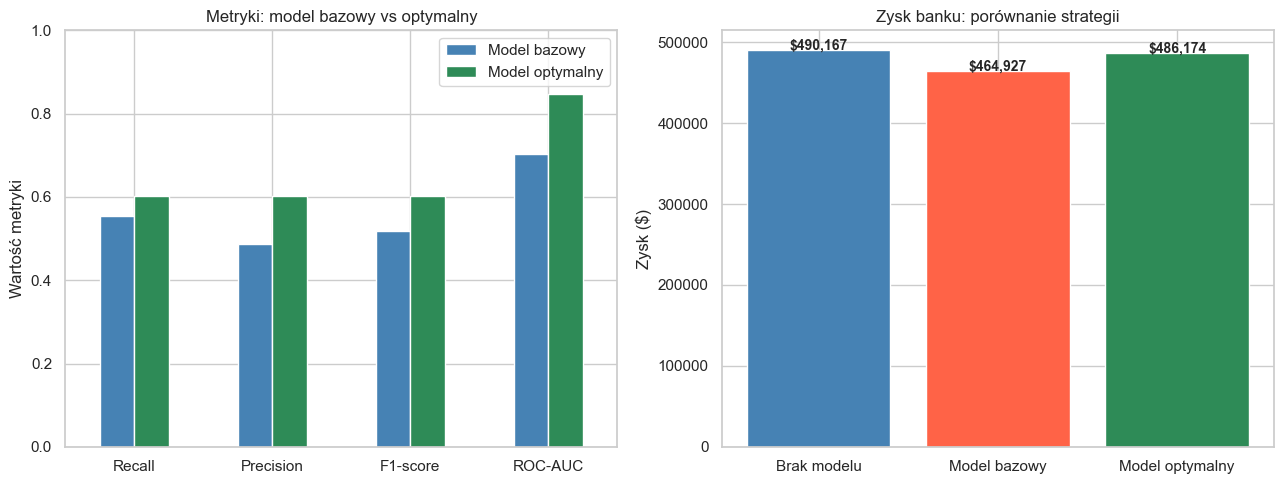

In [130]:
# Wizualizacja porównania

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# metryki
df_metrics.plot(kind="bar", ax=axes[0], color=["steelblue", "seagreen"],
                edgecolor="white", rot=0)
axes[0].set_title("Metryki: model bazowy vs optymalny")
axes[0].set_ylabel("Wartość metryki")
axes[0].legend(["Model bazowy", "Model optymalny"])
axes[0].set_ylim(0, 1)

# zysk
profits = [profit_all_no, profit_model, profit_best]
labels  = ["Brak modelu", "Model bazowy", "Model optymalny"]
colors  = ["steelblue", "tomato", "seagreen"]
bars    = axes[1].bar(labels, profits, color=colors, edgecolor="white")
for bar, val in zip(bars, profits):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f"${val:,.0f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Zysk banku: porównanie strategii")
axes[1].set_ylabel("Zysk ($)")

plt.tight_layout()
plt.show()

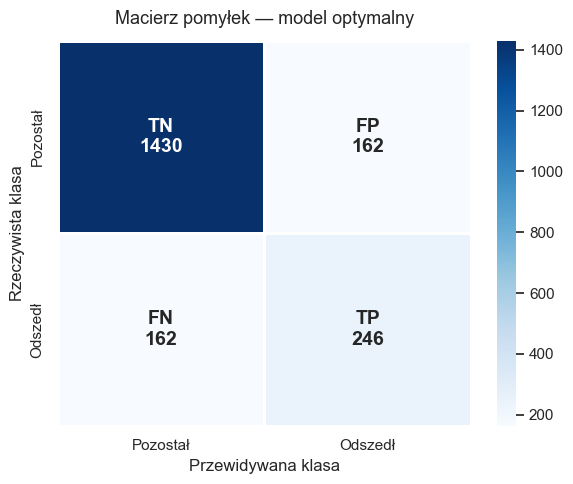

TN: 1430  FP: 162  FN: 162  TP: 246


In [131]:
# Macierz pomyłek najlepszego modelu

cm_best        = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

labels_cm = np.array([
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_best, annot=labels_cm, fmt="", cmap="Blues",
    xticklabels=["Pozostał", "Odszedł"],
    yticklabels=["Pozostał", "Odszedł"],
    linewidths=1, linecolor="white",
    annot_kws={"size": 14, "weight": "bold"}
)
ax.set_xlabel("Przewidywana klasa", fontsize=12)
ax.set_ylabel("Rzeczywista klasa", fontsize=12)
ax.set_title("Macierz pomyłek — model optymalny", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print(f"TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

## 5. dodatkowo - analiza progow

In [132]:
print("=== Domyślny próg decyzyjny w sklearn ===\n")
print("Każdy klasyfikator sklearn domyślnie używa progu 0.5:")
print("  jeśli P(odejdzie) >= 0.5 → predykcja = 'Odszedł'")
print("  jeśli P(odejdzie) <  0.5 → predykcja = 'Pozostał'")
print()
print("Próg 0.5 jest neutralny — traktuje obie klasy jednakowo.")
print("W naszym zadaniu biznesowym to nieoptymalne, bo:")
print("  - FP (fałszywy alarm) = niepotrzebna zniżka = koszt 0.2% salary")
print("  - FN (przeoczenie)    = utrata klienta      = koszt 0.3% salary")
print()
print("Koszty nie są równe → optymalny próg ≠ 0.5")
print("Szukamy progu który maksymalizuje zysk banku.")

=== Domyślny próg decyzyjny w sklearn ===

Każdy klasyfikator sklearn domyślnie używa progu 0.5:
  jeśli P(odejdzie) >= 0.5 → predykcja = 'Odszedł'
  jeśli P(odejdzie) <  0.5 → predykcja = 'Pozostał'

Próg 0.5 jest neutralny — traktuje obie klasy jednakowo.
W naszym zadaniu biznesowym to nieoptymalne, bo:
  - FP (fałszywy alarm) = niepotrzebna zniżka = koszt 0.2% salary
  - FN (przeoczenie)    = utrata klienta      = koszt 0.3% salary

Koszty nie są równe → optymalny próg ≠ 0.5
Szukamy progu który maksymalizuje zysk banku.


In [133]:
thresholds = np.arange(0.1, 0.9, 0.01)
profits_thresh = []

proba_best = dt_best.predict_proba(X_test_scaled)[:, 1]

for thresh in thresholds:
    y_pred_thresh = (proba_best >= thresh).astype(int)
    profits_thresh.append(calculate_profit(y_test, y_pred_thresh, salaries_test_orig))

best_thresh  = thresholds[np.argmax(profits_thresh)]
best_profit  = max(profits_thresh)

print(f"Optymalny próg: {best_thresh:.2f}")
print(f"Maksymalny zysk: ${best_profit:,.2f}")
print(f"Zysk ponad baseline: ${best_profit - profit_all_no:+,.2f}")

Optymalny próg: 0.75
Maksymalny zysk: $498,691.77
Zysk ponad baseline: $+8,524.33


In [71]:
y_pred_best_thresh = (proba_best >= best_thresh).astype(int)

print("PODSUMOWANIE — DRZEWA DECYZYJNE")

print("\n--- Najlepsze hiperparametry (GridSearchCV) ---")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print("\n--- Porównanie metryk na zbiorze testowym ---")
print(f"{'Metryka':<12} {'Bazowy':>10} {'Optymalny':>12} {'Opt. próg':>12}")
print("-" * 50)

metrics_summary = {
    "Recall":    [recall_score(y_test, y_pred_base),
                  recall_score(y_test, y_pred_best),
                  recall_score(y_test, y_pred_best_thresh)],
    "Precision": [precision_score(y_test, y_pred_base),
                  precision_score(y_test, y_pred_best),
                  precision_score(y_test, y_pred_best_thresh)],
    "F1-score":  [f1_score(y_test, y_pred_base),
                  f1_score(y_test, y_pred_best),
                  f1_score(y_test, y_pred_best_thresh)],
    "ROC-AUC":   [roc_auc_score(y_test, dt_base.predict_proba(X_test_scaled)[:, 1]),
                  roc_auc_score(y_test, dt_best.predict_proba(X_test_scaled)[:, 1]),
                  roc_auc_score(y_test, dt_best.predict_proba(X_test_scaled)[:, 1])],
}

for metric, vals in metrics_summary.items():
    print(f"  {metric:<10} {vals[0]:>10.4f} {vals[1]:>12.4f} {vals[2]:>12.4f}")

print("\n--- Porównanie zysku banku ---")
print(f"  Brak modelu:                  ${profit_all_no:>10,.2f}")
print(f"  Model bazowy (próg 0.50):     ${profit_model:>10,.2f}  ({profit_model - profit_all_no:+,.2f})")
print(f"  Model optymalny (próg 0.50):  ${profit_best:>10,.2f}  ({profit_best - profit_all_no:+,.2f})")
print(f"  Model optymalny (próg {best_thresh:.2f}):  ${best_profit:>10,.2f}  ({best_profit - profit_all_no:+,.2f})")

print("\n--- Wnioski ---")
print(f"  1. Model bazowy z domyślnym progiem 0.5 był gorszy od braku modelu.")
print(f"  2. GridSearchCV poprawił F1 z {f1_score(y_test, y_pred_base):.3f} do {f1_score(y_test, y_pred_best):.3f}.")
print(f"  3. Optymalizacja progu ({best_thresh:.2f}) pozwoliła pobić baseline o ${best_profit - profit_all_no:+,.2f}.")
print(f"  4. Kluczowy wniosek: dobór progu decyzyjnego jest równie ważny")
print(f"     jak dobór hiperparametrów modelu.")

PODSUMOWANIE — DRZEWA DECYZYJNE

--- Najlepsze hiperparametry (GridSearchCV) ---
  ccp_alpha: 0.001
  class_weight: {0: 1, 1: 2}
  max_depth: 5

--- Porównanie metryk na zbiorze testowym ---
Metryka          Bazowy    Optymalny    Opt. próg
--------------------------------------------------
  Recall         0.5539       0.6029       0.6765
  Precision      0.4871       0.6029       0.5702
  F1-score       0.5183       0.6029       0.6188
  ROC-AUC        0.7022       0.8482       0.8482

--- Porównanie zysku banku ---
  Brak modelu:                  $-124,071.72
  Model bazowy (próg 0.50):     $-81,791.14  (+42,280.58)
  Model optymalny (próg 0.50):  $-51,346.14  (+72,725.58)
  Model optymalny (próg 0.38):  $-48,222.65  (+75,849.07)

--- Wnioski ---
  1. Model bazowy z domyślnym progiem 0.5 był gorszy od braku modelu.
  2. GridSearchCV poprawił F1 z 0.518 do 0.603.
  3. Optymalizacja progu (0.38) pozwoliła pobić baseline o $+75,849.07.
  4. Kluczowy wniosek: dobór progu decyzyjnego jes

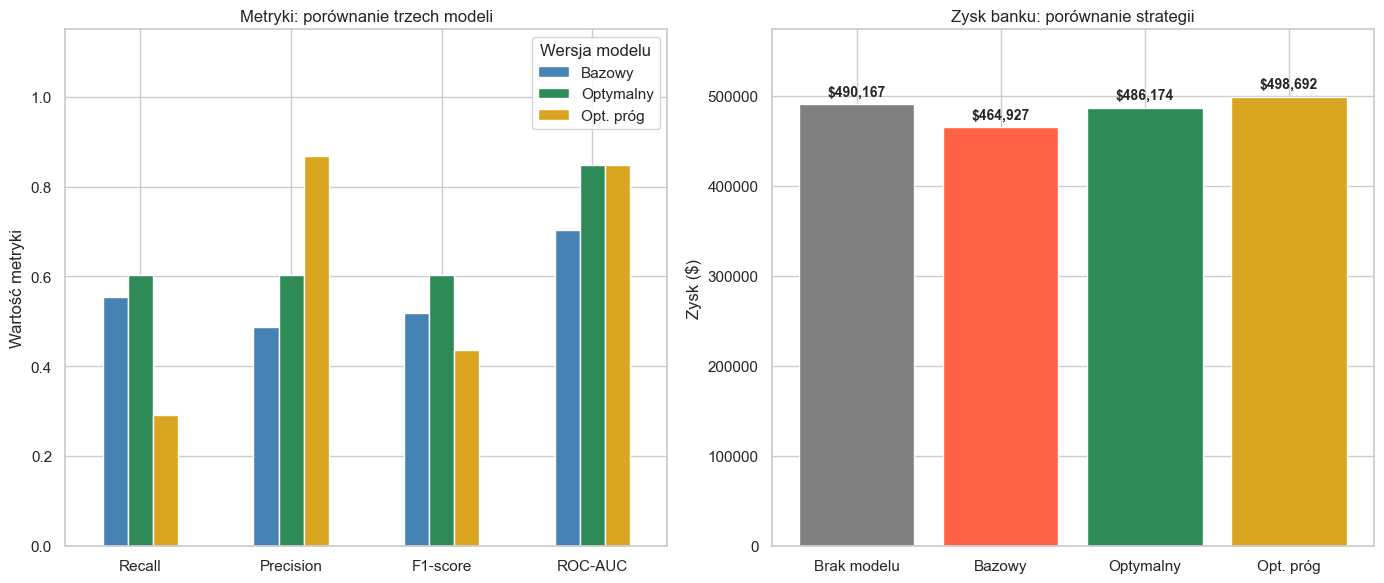

In [135]:
# wykres

import pandas as pd
import matplotlib.pyplot as plt

# 1. Konwersja Twojego słownika 'metrics_summary' na DataFrame
# Transpozycja (.T) sprawi, że metryki będą na osi X, a modele będą seriami (kolorami)
df_metrics = pd.DataFrame(
    metrics_summary, 
    index=["Bazowy", "Optymalny", "Opt. próg"]
).T

# Wizualizacja porównania
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Lekko poszerzamy wykres, żeby zmieścić 4 słupki zysku

# -- WYKRES 1: Metryki --
# Dodajemy trzeci kolor (np. goldenrod lub darkorange) dla optymalnego progu
df_metrics.plot(kind="bar", ax=axes[0], color=["steelblue", "seagreen", "goldenrod"],
                edgecolor="white", rot=0)
axes[0].set_title("Metryki: porównanie trzech modeli")
axes[0].set_ylabel("Wartość metryki")
axes[0].legend(title="Wersja modelu")
# Podnosimy limit osi Y do 1.15, aby legenda nie zasłaniała najwyższych słupków
axes[0].set_ylim(0, 1.15) 

# -- WYKRES 2: Zysk --
# Dodajemy best_profit oraz odpowiednie etykiety i kolory
profits = [profit_all_no, profit_model, profit_best, best_profit]
labels  = ["Brak modelu", "Bazowy", "Optymalny", "Opt. próg"]
colors  = ["gray", "tomato", "seagreen", "goldenrod"] # 'gray' dla braku modelu, reszta konsekwentnie

bars = axes[1].bar(labels, profits, color=colors, edgecolor="white")

# Obliczamy dynamiczny odstęp dla tekstu nad słupkami (np. 2% najwyższej wartości), 
# aby napisy zawsze wyglądały dobrze niezależnie od skali
offset = max(profits) * 0.02 

for bar, val in zip(bars, profits):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                 f"${val:,.0f}", ha="center", fontsize=10, fontweight="bold")
    
axes[1].set_title("Zysk banku: porównanie strategii")
axes[1].set_ylabel("Zysk ($)")
# Dodajemy trochę miejsca z góry na napisy nad słupkami zysku
axes[1].set_ylim(0, max(profits) * 1.15)

plt.tight_layout()
plt.show()